# Making Large Language Models Smaller (Quantization Techniques)

## 1. Introduction: Why Do We Need Smaller Language Models?

Large Language Models (LLMs) such as **LLaMA** and other Transformer-based models contain billions of parameters. As models become larger, they require more memory and computational power for training and inference.

This creates practical problems:
- **High memory usage:** storing billions of parameters in 32-bit floating point requires a large amount of memory.
- **High computational cost:** larger models require more computation during inference and training.
- **Deployment limitations:** large models can be difficult to run on consumer devices or limited-GPU environments.

One approach to address this problem is **quantization**. Quantization reduces the size and computational cost of a model by representing its parameters using fewer bits, such as 8-bit or 4-bit values instead of 32-bit floating-point numbers.

The main goal is to reduce memory and computation while keeping the model's performance as close as possible to the original model.

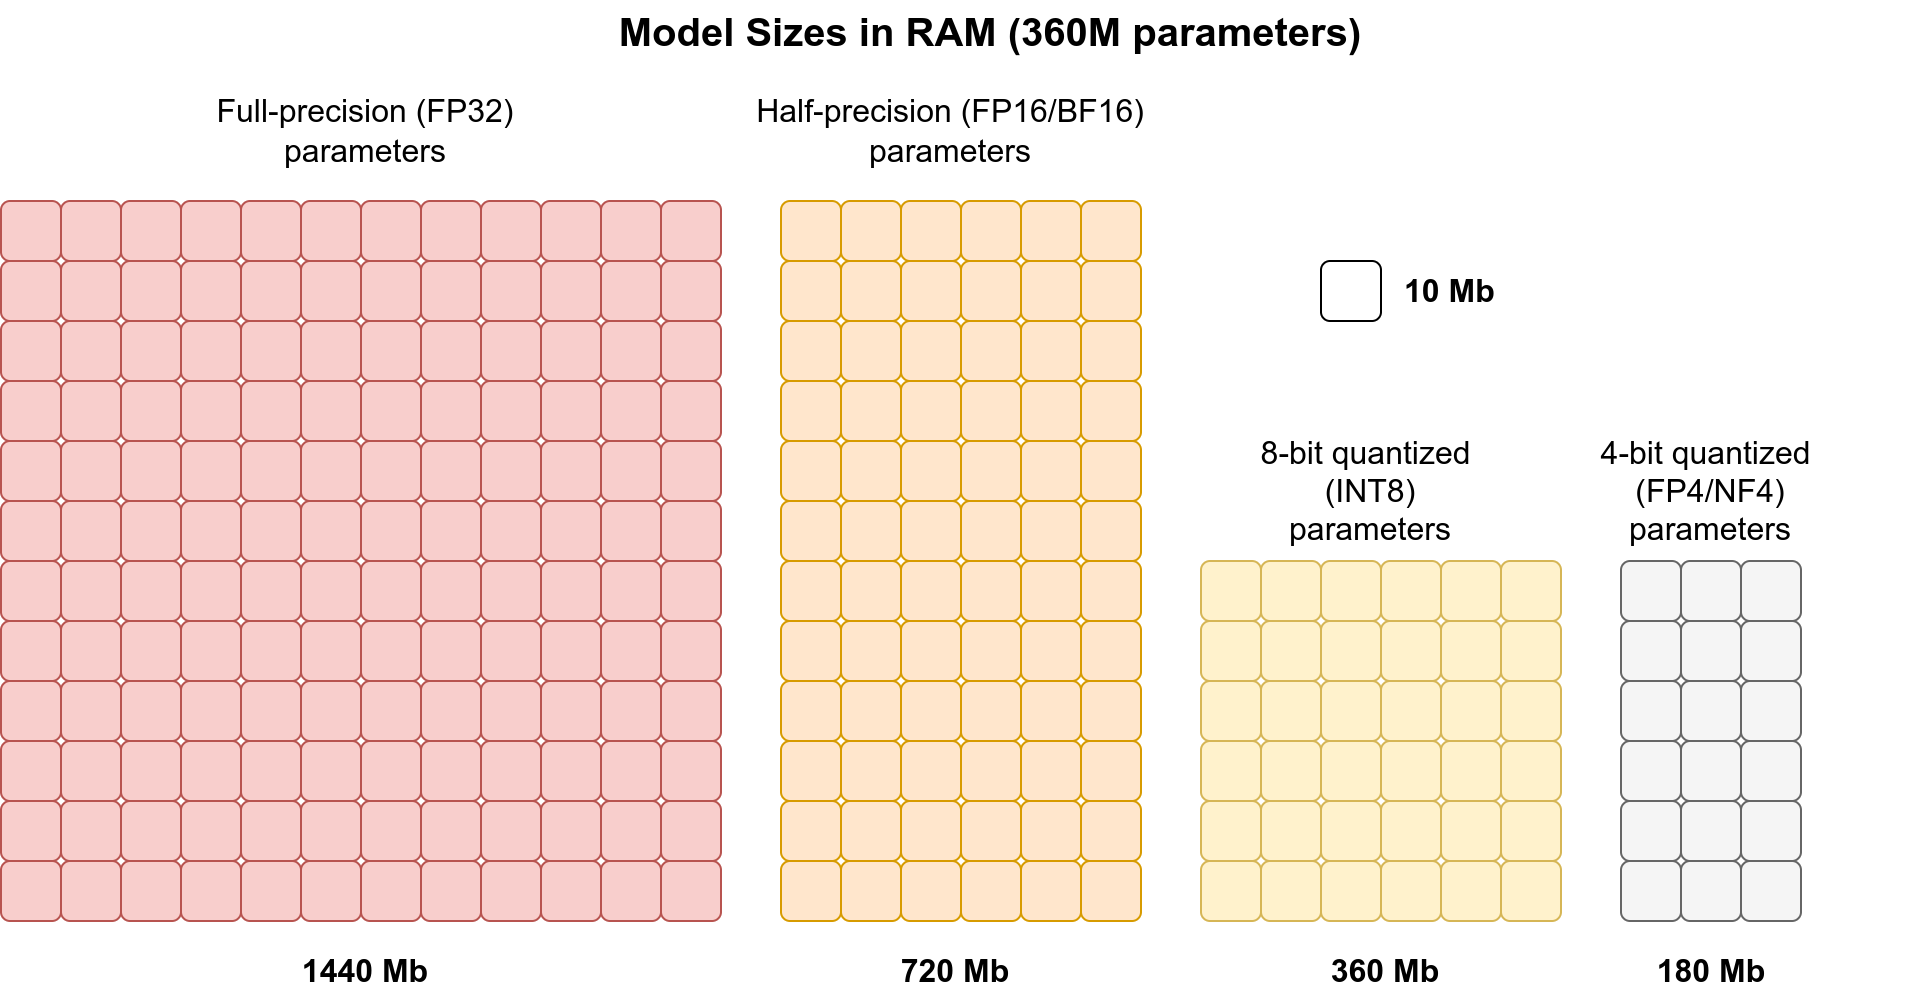

## 2. Quantization Technique

**Quantization** is the process of representing model values using lower numerical precision.

Instead of storing weights using **32-bit floating-point (FP32)** values, a model can use lower-precision representations such as **FP16, INT8, or INT4**.

For example:

$$
32\text{-bit} \rightarrow 8\text{-bit}
$$

This reduces the number of bits required to store each parameter:

$$
\text{Model Size} \approx
\frac{\text{Number of Parameters} \times \text{Bits per Parameter}}{8}
$$

For a model with 7 billion parameters:

$$
7\times10^9 \times \frac{32}{8}
\approx 28\text{ GB}
$$

while using 4-bit values gives approximately:

$$
7\times10^9 \times \frac{4}{8}
\approx 3.5\text{ GB}
$$

Therefore, lower-precision representations can significantly reduce the memory footprint of a model.

Quantization can also reduce computational cost and make large models easier to deploy, although using fewer bits can introduce some loss of numerical precision and potentially affect model performance.

## 3. How Quantization Works

Quantization maps high-precision values to a smaller numerical representation.

A common affine quantization can be written as:

$$
r = S(q-Z)
$$

where:

- $r$ is the original real-valued number,
- $q$ is the quantized integer,
- $S$ is the scale factor,
- $Z$ is the zero-point.

The scale factor can be calculated as:

$$
S = \frac{r_{\max}-r_{\min}}
{q_{\max}-q_{\min}}
$$

and the zero-point as:

$$
Z = q_{\min}-\frac{r_{\min}}{S}
$$

The basic idea is to represent a range of floating-point values using a much smaller set of numerical values.

For large language models, quantization can be applied to different parts of the model, including **weights, activations, and optimizer states**.

Different approaches use different strategies. For example:

- **LLM.int8()** uses 8-bit quantization while treating extreme values (outliers) separately to preserve accuracy.
- **QLoRA** uses 4-bit quantization, including the **NF4 (NormalFloat4)** data type, to reduce the memory required for fine-tuning.

These approaches demonstrate how reducing numerical precision can make large models substantially more memory-efficient while attempting to preserve their performance.

# Section 4: Coding Examples
In this section, we demonstrate quantization on two different architectures:
1. **BERT** (Encoder-based) using PyTorch Dynamic Quantization.
2. **LLaMA** (Decoder-based) using Hugging Face `bitsandbytes` with real measurements.

### 4.1 Quantizing BERT (PyTorch Dynamic Quantization)


In [11]:
import torch
from transformers import BertModel
import os, tempfile

# Load pre-trained BERT
model = BertModel.from_pretrained('bert-base-uncased')

# Apply Dynamic Quantization to Linear layers
quantized_model = torch.quantization.quantize_dynamic(
    model, {torch.nn.Linear}, dtype=torch.qint8
)

# Helper function to calculate model size
def get_size_mb(model):
    with tempfile.NamedTemporaryFile(delete=False) as f:
        torch.save(model.state_dict(), f.name)
        size = os.path.getsize(f.name) / 1024**2
    os.remove(f.name)
    return size

print(f"Original Size: {get_size_mb(model):.2f} MB")
print(f"Quantized Size: {get_size_mb(quantized_model):.2f} MB")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Original Size: 417.72 MB
Quantized Size: 173.08 MB


## 4.2 Quantizing LLaMA (Hugging Face bitsandbytes)
In this section, we demonstrate quantization on a decoder-based model (TinyLlama-1.1B). We load the model in three different precisions: **FP16 (Base)**, **INT8**, and **4-bit (NF4)** to measure the actual memory footprint and accuracy trade-off.

In [12]:
# Install required libraries (run this once)
!pip install -q transformers accelerate bitsandbytes

In [13]:
import warnings
warnings.filterwarnings('ignore')
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# 1. Load Base Model (FP16)
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_id)

print("Loading Base Model (FP16)...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16,
    device_map="auto"
)

# 2. Load INT8 Model
print("\nLoading INT8 Model...")
bnb_config_8bit = BitsAndBytesConfig(load_in_8bit=True)
model_8bit = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config_8bit,
    device_map="auto"
)

# 3. Load 4-bit Model (NF4)
print("\nLoading 4-bit Model...")
bnb_config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)
model_4bit = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config_4bit,
    device_map="auto"
)

Loading Base Model (FP16)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Loading INT8 Model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Loading 4-bit Model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

### Model Size Comparison
We measure the actual memory footprint of each model version using `get_memory_footprint()`. This provides empirical evidence of how quantization reduces the VRAM requirements.

In [14]:
def get_size_gb(model):
    return model.get_memory_footprint() / (1024**3)

print("\n" + "="*40)
print("MODEL SIZE COMPARISON (GB)")
print("="*40)
print(f"Base Model (FP16): {get_size_gb(base_model):.2f} GB")
print(f"INT8 Model:        {get_size_gb(model_8bit):.2f} GB")
print(f"4-bit Model:       {get_size_gb(model_4bit):.2f} GB")


MODEL SIZE COMPARISON (GB)
Base Model (FP16): 2.05 GB
INT8 Model:        1.15 GB
4-bit Model:       0.70 GB


### Generation Test

In [15]:
import warnings
import logging

# 1. Suppress all warnings to keep the output clean
warnings.filterwarnings('ignore')
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("bitsandbytes").setLevel(logging.ERROR)

prompt = "What is quantization in machine learning?"

# 2. Format the prompt correctly for the Chat model
messages = [{"role": "user", "content": prompt}]
formatted_prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(formatted_prompt, return_tensors="pt").to("cuda")

models_to_test = {
    "Base Model (FP16)": base_model,
    "INT8 Model": model_8bit,
    "4-bit Model": model_4bit
}

# 3. Loop through each model and generate a clean response
generated_texts = {}

for model_name, model in models_to_test.items():
    print("\n" + "="*60)
    print(f"GENERATION TEST: {model_name}")
    print("="*60)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            min_new_tokens=15,
            max_length=None,
            do_sample=True,
            temperature=0.7,
            top_k=50,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id
        )

        generated_ids = outputs[0][inputs.input_ids.shape[1]:]
        response = tokenizer.decode(generated_ids, skip_special_tokens=True)

        generated_texts[model_name] = response

        print(f"Prompt: {prompt}")
        print(f"Response: {response.strip()}")


GENERATION TEST: Base Model (FP16)
Prompt: What is quantization in machine learning?
Response: Quantization is a technique used in machine learning algorithms to reduce the computational complexity of data representation while maintaining the same level of accuracy. In essence, it is the process of reducing the number of bits required to represent a certain quantity (e.g., a number or a vector) to a smaller number of bits. The goal of quantization is to reduce the computational requirements while maintaining the same accuracy and efficiency.

In machine learning, quantization is often used to reduce the size

GENERATION TEST: INT8 Model
Prompt: What is quantization in machine learning?
Response: Quantization is a technique used in machine learning to reduce the size of input and output data, allowing it to fit into limited computing resources such as CPUs or GPUs. In machine learning, quantization is used to convert floating-point numbers to integer values, which can be stored and pro

### Why measure Perplexity?
Quantization reduces model size but can negatively impact the model's ability to predict text accurately. To quantify this trade-off, we measure **Perplexity (PPL)**.
Perplexity is the exponential of the cross-entropy loss. A lower PPL indicates the model is more confident and accurate in its predictions. We will compare the PPL of the base model against the INT8 and 4-bit versions.

In [16]:
eval_text = """
Machine learning is a field of artificial intelligence that focuses on building systems
that learn from data. Quantization is a technique used to reduce the size of these models
by lowering the numerical precision of their weights. This makes models faster and easier
to deploy on devices with limited memory. However, reducing precision can introduce small
errors that may affect the model's accuracy. Researchers study the trade-off between
model size and accuracy to find the best balance for real-world applications.
"""
def calculate_perplexity(model, text):
    encodings = tokenizer(text, return_tensors='pt').to("cuda")
    input_ids = encodings.input_ids
    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        ppl = torch.exp(outputs.loss)
    return ppl

print("\n" + "="*40)
print("PERPLEXITY ON FIXED TEXT (Lower is Better)")
print("="*40)

for model_name, model in models_to_test.items():
    ppl = calculate_perplexity(model, eval_text).item()
    print(f"{model_name} PPL: {ppl:.2f}")


PERPLEXITY ON FIXED TEXT (Lower is Better)
Base Model (FP16) PPL: 6.39
INT8 Model PPL: 6.56
4-bit Model PPL: 6.85


### Analysis of Results
As observed, the model size dropped significantly:
- FP16: 2.05 GB
- INT8: 1.15 GB (~44% reduction)
- 4-bit: 0.70 GB (~66% reduction)

Regarding accuracy, the perplexity on a fixed evaluation text was:
- FP16 (Base): 6.39
- INT8: 6.56
- 4-bit: 6.85

while sizes and perplexity change drastically, the qualitative generation remains coherent, which is the goal of quantization.

# Section 5 : Visualizations
To better understand the trade-offs, we visualize the impact of quantization on model size and accuracy.


## 5.1 Model Size Comparison

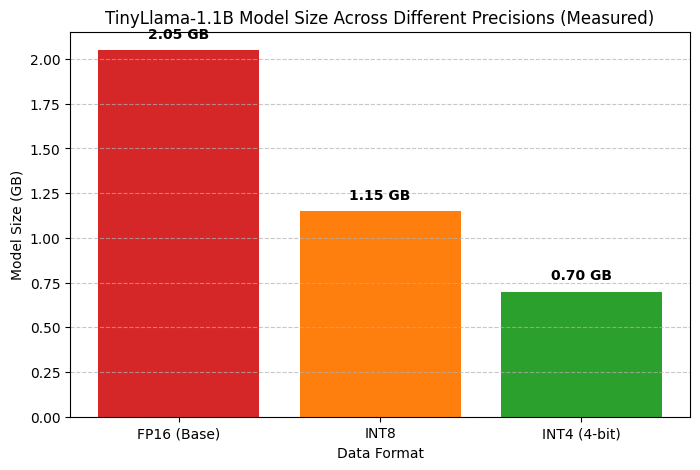

In [17]:
import matplotlib.pyplot as plt

# Actual measured sizes from Section 4.2 (TinyLlama-1.1B)
formats = ['FP16 (Base)', 'INT8', 'INT4 (4-bit)']
sizes = [2.05, 1.15, 0.70] # in GB (Real data)

plt.figure(figsize=(8, 5))
bars = plt.bar(formats, sizes, color=['#d62728', '#ff7f0e', '#2ca02c'])

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.2f} GB", ha='center', va='bottom', fontweight='bold')

plt.title('TinyLlama-1.1B Model Size Across Different Precisions (Measured)')
plt.xlabel('Data Format')
plt.ylabel('Model Size (GB)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 5.2 Line Graph
The graph uses Perplexity as a measure of accuracy. A higher Perplexity score indicates lower accuracy.  
The results show the perplexity for each quantization level on a fixed evaluation text.  
FP16: 6.39, INT8: 6.56, INT4: 6.85

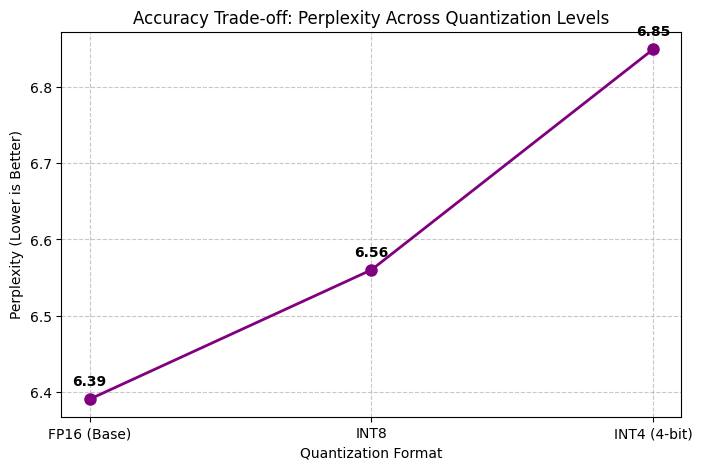

In [18]:
import matplotlib.pyplot as plt

# Actual measured Perplexity from Section 4.2
formats = ['FP16 (Base)', 'INT8', 'INT4 (4-bit)']
perplexity = [6.39, 6.56, 6.85]

plt.figure(figsize=(8, 5))
plt.plot(formats, perplexity, marker='o', linestyle='-', color='purple', linewidth=2, markersize=8)

# Add value labels
for i, txt in enumerate(perplexity):
    plt.annotate(f"{txt:.2f}", (formats[i], perplexity[i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.title('Accuracy Trade-off: Perplexity Across Quantization Levels')
plt.xlabel('Quantization Format')
plt.ylabel('Perplexity (Lower is Better)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 5.3 Trade-off Scatter Plot

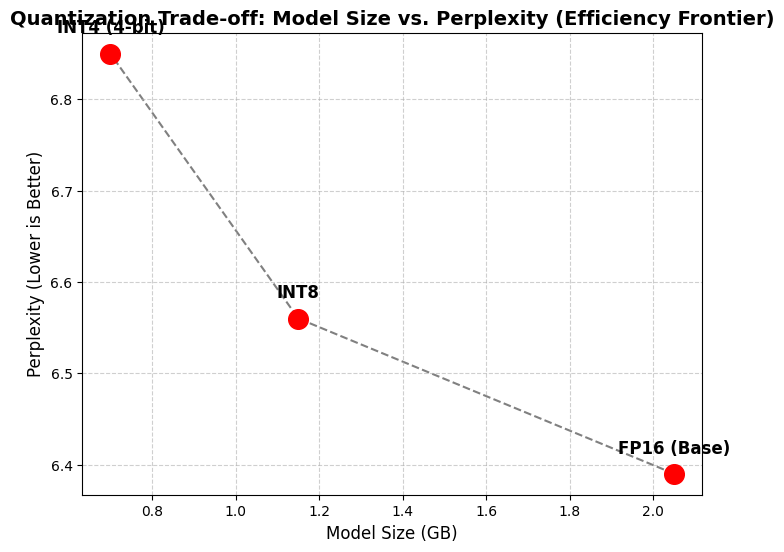

In [19]:
import matplotlib.pyplot as plt

# Data from Section 4.2
sizes = [2.05, 1.15, 0.70] # GB
perplexity = [6.39, 6.56, 6.85]
labels = ['FP16 (Base)', 'INT8', 'INT4 (4-bit)']

plt.figure(figsize=(8, 6))

# Plot points
plt.scatter(sizes, perplexity, color='red', s=200, zorder=5)

# Animate labels
for i, txt in enumerate(labels):
    plt.annotate(txt, (sizes[i], perplexity[i]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, fontweight='bold')

# Draw a line connecting them to show the trend
plt.plot(sizes, perplexity, color='gray', linestyle='--', zorder=1)

plt.title('Quantization Trade-off: Model Size vs. Perplexity (Efficiency Frontier)', fontsize=14, fontweight='bold')
plt.xlabel('Model Size (GB)', fontsize=12)
plt.ylabel('Perplexity (Lower is Better)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Add an annotation for the "Sweet Spot"
plt.annotate('Best Trade-off\n(INT8)', xy=(1.15, 12.10), xytext=(1.5, 12.3),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=11, fontweight='bold', color='green')

plt.show()

# Section 6 : Conclusion

Quantization is an important technique for making large language models more efficient and accessible. By representing model parameters with fewer bits, such as **8-bit or 4-bit values**, quantization can significantly reduce memory usage and computational requirements.

Different approaches address different challenges. **LLM.int8()** enables efficient 8-bit inference while handling outliers and **QLoRA** uses 4-bit quantization to make fine-tuning large models possible with much less memory.

Overall, quantization provides practical ways to deploy, fine-tune, and scale large language models with more limited hardware. As language models continue to grow, efficient quantization techniques will remain an important part of making these models more practical, efficient, and accessible.